# **Titanic Survival Prediction**


## **Objective**
- Build a machine learning model to predict whether a passenger suvived the Titanic accident.

### **Goal**
- Understand the dataset
- Perform data cleaning
- Explore the data using visualizations
- Engineer useful features that might improve model performance
- Train and evaluate models

## **Import Libraries**

In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

## **Load Dataset**

In [2]:
# Load the dataset
df_titanic = pd.read_csv('Titanic-Dataset.csv')
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Data Overview**

In [3]:
# checking for the data types
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Statistical info of the columns
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## **Data Cleaning**

In [5]:
# checking for null values
df_titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# drop columns we are not going to use for our model
# ticket is dropped(doesnt add much meaning to the predictions), cabin has too many missing values and hard to extract meaning from it
# PassengerID is just an ID
df_titanic.drop(['Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)

In [7]:
df_titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [8]:
# filling the age with the median age
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

In [9]:
# fill the missing gap with mode for categorical values of the embarked column
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])

In [10]:
# Rename some columns to give them more clarity
df_titanic.rename(columns={
    'Pclass': 'Passenger class',
    'SibSp': 'NumSiblingSpouse',
    'Parch': 'parents/children'}, inplace=True)

In [11]:
df_titanic.head()

,Survived,Passenger class,Name,Sex,Age,NumSiblingSpouse,parents/children,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [12]:
# No more missing values, they have been filled up
df_titanic.isna().sum()

Survived            0
Passenger class     0
Name                0
Sex                 0
Age                 0
NumSiblingSpouse    0
parents/children    0
Fare                0
Embarked            0
dtype: int64

## **Data Exploration**
- Exploring key patterns in survival using visualizations

#### **Survival Distribution**

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

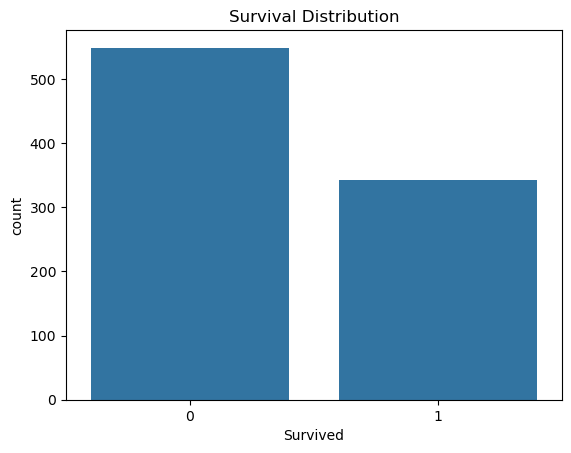

In [14]:
sns.countplot(x='Survived', data=df_titanic)
plt.title("Survival Distribution")
plt.show()

**Insights:**
- Those who did not survive are more than those who survived in the titanic
- 0 stands for those who **_did not survive_** and the 1 stands for those who **_survived_**

#### **Survival by Gender**

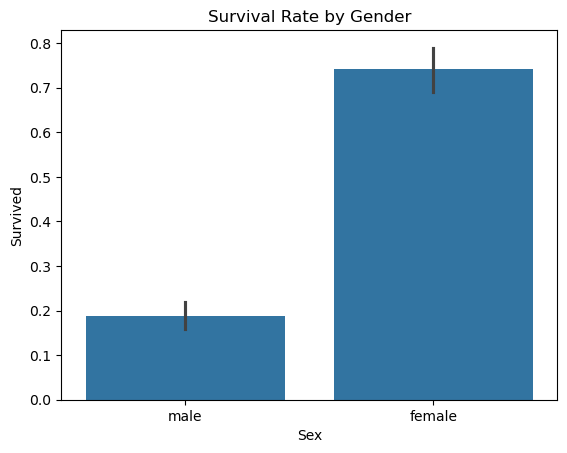

In [15]:
sns.barplot(x='Sex', y='Survived', data=df_titanic)
plt.title('Survival Rate by Gender')
plt.show()

**Insights**
- The 0 stands for **_males_** and the 1 stands for the **_females_**
- More females survived more than the males

#### **Survival by Class**

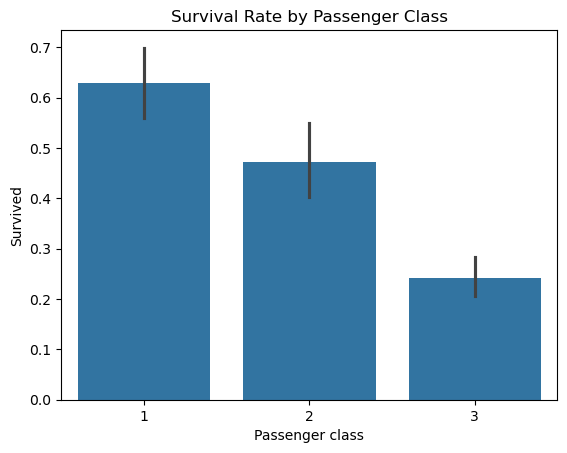

In [16]:
sns.barplot(x='Passenger class', y='Survived', data=df_titanic)
plt.title("Survival Rate by Passenger Class")
plt.show()

#### **Insights**
- People in the first class had the highest chance of surviving

#### **Insights**
- The Sex feature strongly influences the survival of the passengers in the titanic

## **Feature Encoding Categorical Values**

In [17]:
# Label encoding the Sex column since it has binary values, used map to map them to the numerical values
df_titanic['Sex'] = df_titanic['Sex'].map({'male':0, 'female':1})

In [18]:
# One-hot encoding the embarked categorical values since they are more than 2
df_titanic = pd.get_dummies(df_titanic, columns=['Embarked'], drop_first=True)

In [19]:
df_titanic.info()
# The embarked categorical values become boolean values and sex column values become integers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Survived          891 non-null    int64  
 1   Passenger class   891 non-null    int64  
 2   Name              891 non-null    object 
 3   Sex               891 non-null    int64  
 4   Age               891 non-null    float64
 5   NumSiblingSpouse  891 non-null    int64  
 6   parents/children  891 non-null    int64  
 7   Fare              891 non-null    float64
 8   Embarked_Q        891 non-null    bool   
 9   Embarked_S        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(1)
memory usage: 57.6+ KB


In [20]:
df_titanic.head()
# 0 is for males and 1 is for females

,Survived,Passenger class,Name,Sex,Age,NumSiblingSpouse,parents/children,Fare,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,False,False
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,False,True
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,False,True


# **Training Model before feature engineering**

## **Splitting the Data**

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# Assigning the target and features, X are the features and y is the target
X = df_titanic.drop(['Survived','Name'], axis=1)
y = df_titanic['Survived']

# Splitting the data into training and test data, test data is 20% and training data is 80%
#  the random state helps produce the same results everytime the test is ran
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Model training**
- Training the model before feature engineering

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [24]:
# set the maximum iteration to 1000 to give the model more time to learn the data
Lr = LogisticRegression(max_iter=1000)
Lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
# predicting on the x_test values(features)
y_pred = Lr.predict(X_test)

## **Model Evaluation**

In [26]:
# getting accuracy predictions
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


In [27]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## **Feature Engineering**
- This is done to see if there will be any improvement to the model performance

In [28]:
#  adding the numsibling and the parent/child column to make one family in a new column
# the 1 adds the passenger themselves
df_titanic['FamilySize'] = df_titanic['NumSiblingSpouse'] + df_titanic['parents/children'] + 1

In [29]:
# drop the numsibling spouse and parents/children columns
df_titanic = df_titanic.drop(df_titanic[['NumSiblingSpouse', 'parents/children']], axis=1)

In [30]:
# create new column for if a passenger is alone
df_titanic['IsAlone'] = (df_titanic['FamilySize']==1).astype(int)

In [31]:
# extracting titles from the names
# space, all letters and then the dot ([A-Za-z]+)\.)
df_titanic['Title'] = df_titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [32]:
# Showing all the different titles in the title column
df_titanic['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [33]:
# grouping the titles into categories of their titles by replaccing them with a category
df_titanic['Title'] = df_titanic['Title'].replace(['Mlle','Ms'], 'Miss')
df_titanic['Title'] = df_titanic['Title'].replace(['Mme'], 'Mrs')

df_titanic['Title'] = df_titanic['Title'].replace(['Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Col', 'Capt', 'Countess',
       'Jonkheer'], 'Rare')

In [34]:
df_titanic.head(10)

,Survived,Passenger class,Name,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title
0,0,3,"Braund, Mr. Owen Harris",0,22.0,7.2500,False,True,2,0,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,71.2833,False,False,2,0,Mrs
2,1,3,"Heikkinen, Miss. Laina",1,26.0,7.9250,False,True,1,1,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,53.1000,False,True,2,0,Mrs
4,0,3,"Allen, Mr. William Henry",0,35.0,8.0500,False,True,1,1,Mr
5,0,3,"Moran, Mr. James",0,28.0,8.4583,True,False,1,1,Mr
6,0,1,"McCarthy, Mr. Timothy J",0,54.0,51.8625,False,True,1,1,Mr
7,0,3,"Palsson, Master. Gosta Leonard",0,2.0,21.0750,False,True,5,0,Master
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,11.1333,False,True,3,0,Mrs
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,30.0708,False,False,2,0,Mrs


In [35]:
# One-hot encode the titles in the dataset
df_titanic = pd.get_dummies(df_titanic, columns=['Title'], drop_first=True)

In [36]:
# drop the names column
df_titanic = df_titanic.drop('Name', axis=1)

In [37]:
df_titanic.head(10)

,Survived,Passenger class,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,7.2500,False,True,2,0,False,True,False,False
1,1,1,1,38.0,71.2833,False,False,2,0,False,False,True,False
2,1,3,1,26.0,7.9250,False,True,1,1,True,False,False,False
3,1,1,1,35.0,53.1000,False,True,2,0,False,False,True,False
4,0,3,0,35.0,8.0500,False,True,1,1,False,True,False,False
5,0,3,0,28.0,8.4583,True,False,1,1,False,True,False,False
6,0,1,0,54.0,51.8625,False,True,1,1,False,True,False,False
7,0,3,0,2.0,21.0750,False,True,5,0,False,False,False,False
8,1,3,1,27.0,11.1333,False,True,3,0,False,False,True,False
9,1,2,1,14.0,30.0708,False,False,2,0,False,False,True,False


### **Which features influence survival**

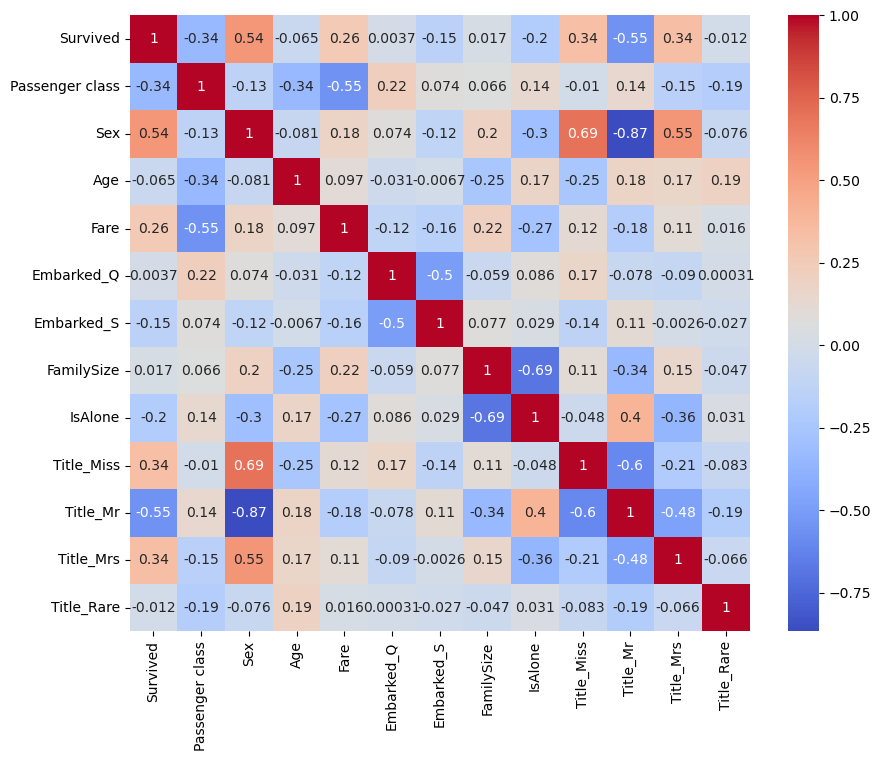

In [38]:
# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_titanic.corr(), annot=True, cmap='coolwarm')
plt.show()

In [39]:
df_titanic.corr()['Survived'].sort_values(ascending=False)

Survived           1.000000
Sex                0.543351
Title_Mrs          0.341994
Title_Miss         0.335636
Fare               0.257307
FamilySize         0.016639
Embarked_Q         0.003650
Title_Rare        -0.012054
Age               -0.064910
Embarked_S        -0.149683
IsAlone           -0.203367
Passenger class   -0.338481
Title_Mr          -0.549199
Name: Survived, dtype: float64

#### **Insights**
- The Sex feature strongly influences the survival of the passengers in the titanic

### **Scaling the data**

In [40]:
# scaling the data on different scales with the standardscaler to standardize the values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Training the model on engineered features**

## **Splitting the data and model training**

In [41]:
# split the data again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
Lr = LogisticRegression(max_iter=1000)
Lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [42]:
# Make predictions
y_pred = Lr.predict(X_test)

## **Model Evaluation**

In [43]:
# Run the metrics to see the model improvements
# accuracy predictions
print('Accuracy:', accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8100558659217877
[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## **Using the Random Forest Classifier for predictions**
- This is to improve the predictions of the data
- The Random Forest Classifier captures non-linear relationships in the data which might improve performance

In [44]:
from sklearn.ensemble import RandomForestClassifier

Rfc = RandomForestClassifier(
    n_estimators=200, # how many trees the model should build and combine their results
    random_state=42
)

Rfc.fit(X_train, y_train)
y_pred = Rfc.predict(X_test)

## **Model Evaluation**

In [45]:
# Run the metrics to see the model improvements
# accuracy predictions
print('Accuracy:', accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.8100558659217877
[[89 16]
 [18 56]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

